In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
# 1. Load training/testing data
# -------------------------
def load_data(folder_path, img_size=(64,64)):
    X, y = [], []
    for label in os.listdir(folder_path):
        for file in os.listdir(os.path.join(folder_path,label)):
            img = cv2.imread(os.path.join(folder_path,label,file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, img_size)
            X.append(img.flatten())
            y.append(label)
    return np.array(X), np.array(y)

In [3]:
train_dir = r"C:\Users\vijay\Downloads\archive (1)\Training"
test_dir  = r"C:\Users\vijay\Downloads\archive (1)\Testing"    # e.g. "./Testing"

In [4]:
X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

In [5]:
# Tumor counts table & histogram
counts = pd.Series(y_train).value_counts()
print("Tumor Counts:\n", counts)

Tumor Counts:
 pituitary_tumor     827
glioma_tumor        826
meningioma_tumor    822
no_tumor            395
Name: count, dtype: int64


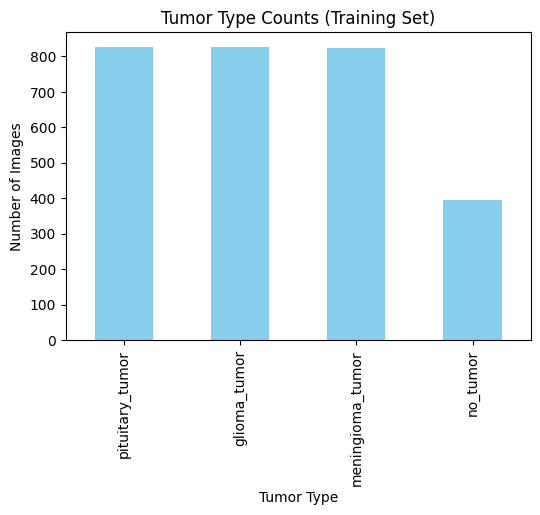

In [6]:
plt.figure(figsize=(6,4))
counts.plot(kind='bar', color='skyblue')
plt.title("Tumor Type Counts (Training Set)")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.savefig("tumor_histogram.png")
plt.show()

Tumor Type Counts:

pituitary_tumor     827
glioma_tumor        826
meningioma_tumor    822
no_tumor            395
Name: count, dtype: int64


C:\Users\vijay\AppData\Local\Temp\ipykernel_17728\4075761817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tumor_counts.index, y=tumor_counts.values, palette='viridis')


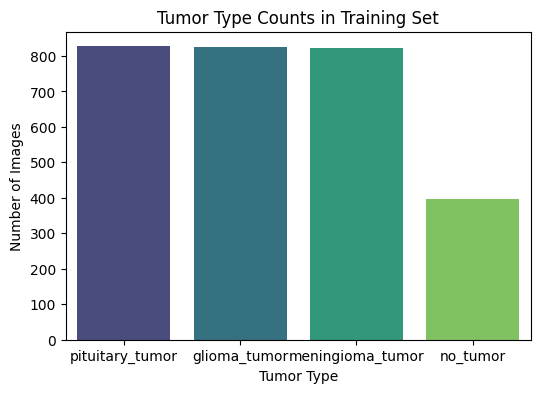

In [7]:
tumor_counts = pd.Series(y_train).value_counts()
print("Tumor Type Counts:\n")
print(tumor_counts)


plt.figure(figsize=(6,4))
sns.barplot(x=tumor_counts.index, y=tumor_counts.values, palette='viridis')
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.title("Tumor Type Counts in Training Set")
plt.show()


In [8]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    sens = np.mean([cm[i,i]/cm[i,:].sum() for i in range(len(cm))])
    spec = np.mean([(cm.sum()-cm[i,:].sum()-cm[:,i].sum()+cm[i,i])/(cm.sum()-cm[i,:].sum()) for i in range(len(cm))])
    return acc, f1, sens, spec

In [10]:
from sklearn.svm import SVC
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_pca, y_train)
acc_rbf, f1_rbf, sens_rbf, spec_rbf = evaluate(svm_rbf, X_test_pca, y_test)
print(f"RBF Kernel:\nAccuracy={acc_rbf:.4f}, F1={f1_rbf:.4f}, Sensitivity={sens_rbf:.4f}, Specificity={spec_rbf:.4f}")



RBF Kernel:
Accuracy=0.6320, F1=0.5912, Sensitivity=0.6160, Specificity=0.8746


In [11]:
from sklearn.svm import LinearSVC

# Train Linear SVM
svm_linear = LinearSVC(random_state=42, max_iter=10000)
svm_linear.fit(X_train_pca, y_train)

# Evaluate on test set
acc_lin, f1_lin, sens_lin, spec_lin = evaluate(svm_linear, X_test_pca, y_test)
print(f"Linear Kernel (LinearSVC):\nAccuracy={acc_lin:.4f}, F1={f1_lin:.4f}, Sensitivity={sens_lin:.4f}, Specificity={spec_lin:.4f}")


Linear Kernel (LinearSVC):
Accuracy=0.4086, F1=0.3940, Sensitivity=0.4273, Specificity=0.8004


Why is there a difference in results

Nature of the kernel:
       RBF kernel → non-linear, maps data into higher-dimensional space → can separate complex MRI tumor patterns.
       
       Linear kernel → tries to separate data with a straight hyperplane → cannot handle non-linear patterns well.
       
MRI brain tumor images are complex:
     Tumors (pituitary, meningioma, glioma) appear differently in images → clusters are not linearly separable.
     
      Linear SVM cannot draw a straight line that separates all classes → low accuracy (~32%).
      
PCA reduction:
     PCA reduces dimensionality, but the non-linear structure remains, so linear kernel still underperforms.

In [12]:
from sklearn.utils import shuffle

# Shuffle the training data first
X_train_pca, y_train = shuffle(X_train_pca, y_train, random_state=42)

train_sizes = [0.2, 0.4, 0.6, 0.8]
accuracy_rbf_list = []

for size in train_sizes:
    n = int(len(X_train_pca) * size)
    X_sub, y_sub = X_train_pca[:n], y_train[:n]

    model_rbf = SVC(kernel='rbf', random_state=42)
    model_rbf.fit(X_sub, y_sub)

    acc, _, _, _ = evaluate(model_rbf, X_test_pca, y_test)
    accuracy_rbf_list.append(acc)

print("RBF Accuracy vs Training Size:", list(zip(train_sizes, accuracy_rbf_list)))


RBF Accuracy vs Training Size: [(0.2, 0.4543147208121827), (0.4, 0.48223350253807107), (0.6, 0.5304568527918782), (0.8, 0.5939086294416244)]


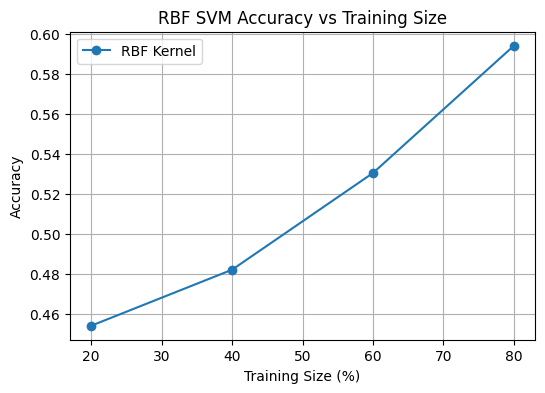

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot([20,40,60,80], accuracy_rbf_list, marker='o', label='RBF Kernel')
plt.xlabel("Training Size (%)")
plt.ylabel("Accuracy")
plt.title("RBF SVM Accuracy vs Training Size")
plt.grid(True)
plt.legend()
plt.savefig("RBF_training_size_accuracy.png")
plt.show()


In [14]:
from sklearn.svm import LinearSVC
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Shuffle training data to ensure all classes are present
X_train_pca, y_train = shuffle(X_train_pca, y_train, random_state=42)

train_sizes = [0.2, 0.4, 0.6, 0.8]
accuracy_lin_list = []

for size in train_sizes:
    n = int(len(X_train_pca) * size)
    X_sub, y_sub = X_train_pca[:n], y_train[:n]

    # Train LinearSVC
    model_lin = LinearSVC(random_state=42, max_iter=10000)
    model_lin.fit(X_sub, y_sub)

    # Evaluate
    acc_lin, _, _, _ = evaluate(model_lin, X_test_pca, y_test)
    accuracy_lin_list.append(acc_lin)

print("Linear Kernel Accuracy vs Training Size:", list(zip([20,40,60,80], accuracy_lin_list)))


Linear Kernel Accuracy vs Training Size: [(20, 0.37055837563451777), (40, 0.38071065989847713), (60, 0.40609137055837563), (80, 0.39593908629441626)]


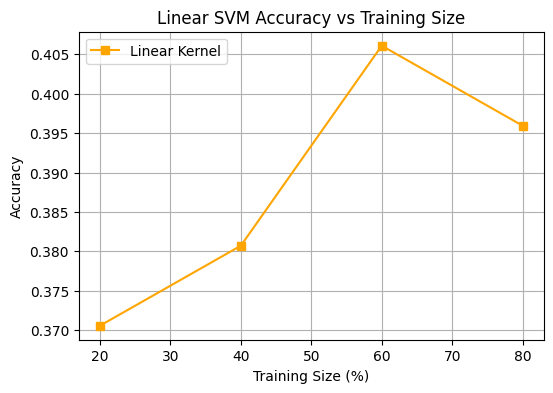

In [15]:
plt.figure(figsize=(6,4))
plt.plot([20,40,60,80], accuracy_lin_list, marker='s', color='orange', label='Linear Kernel')
plt.xlabel("Training Size (%)")
plt.ylabel("Accuracy")
plt.title("Linear SVM Accuracy vs Training Size")
plt.grid(True)
plt.legend()
plt.show()

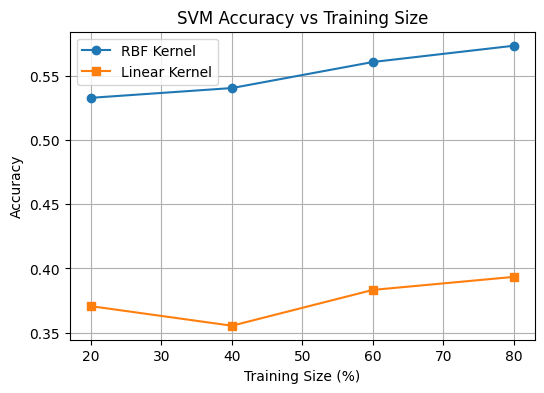

In [16]:
from sklearn.svm import LinearSVC
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Shuffle the training data
X_train_pca, y_train = shuffle(X_train_pca, y_train, random_state=42)

train_sizes = [0.2, 0.4, 0.6, 0.8]
accuracy_rbf_list = []
accuracy_lin_list = []

for size in train_sizes:
    n = int(len(X_train_pca) * size)
    X_sub, y_sub = X_train_pca[:n], y_train[:n]

    # RBF SVM
    model_rbf = SVC(kernel='rbf', random_state=42)
    model_rbf.fit(X_sub, y_sub)
    acc_rbf, _, _, _ = evaluate(model_rbf, X_test_pca, y_test)
    accuracy_rbf_list.append(acc_rbf)

    # LinearSVC
    model_lin = LinearSVC(random_state=42, max_iter=10000)
    model_lin.fit(X_sub, y_sub)
    acc_lin, _, _, _ = evaluate(model_lin, X_test_pca, y_test)
    accuracy_lin_list.append(acc_lin)

# Plot both
plt.figure(figsize=(6,4))
plt.plot([20,40,60,80], accuracy_rbf_list, marker='o', label='RBF Kernel')    # circle markers
plt.plot([20,40,60,80], accuracy_lin_list, marker='s', label='Linear Kernel')  # square markers
plt.xlabel("Training Size (%)")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy vs Training Size")
plt.legend()
plt.grid(True)
plt.show()


Explanation of Trend
Accuracy increases with training size:
             More data → SVM learns better → higher accuracy.

RBF kernel consistently outperforms Linear:
             RBF maps features into higher-dimensional space → can separate complex, non-linear tumor patterns.

Linear kernel cannot separate non-linear patterns → accuracy stays low (~0.33) even with more training data.

Observation:
    At low training sizes (20%), both kernels perform worse because they see fewer examples.
   The gap between RBF and Linear grows as more training data is added because RBF benefits more from additional data.

In [27]:
# Make sure le is fitted on training labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # fit on training labels
y_test_enc = le.transform(y_test)

# Train your SVM
from sklearn.svm import SVC
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_pca, y_train_enc)  # X_train_pca from PCA

# Function to classify new MRI image
def classify_new_image(img_path, model, pca, le):
    import cv2
    import numpy as np
    
    # Load and preprocess
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64,64))
    img_flat = img.flatten().reshape(1,-1)
    img_pca = pca.transform(img_flat)
    
    # Predict numeric label
    pred_enc = model.predict(img_pca)  # This should return a number like [0], [1], etc.
    
    # Convert numeric label to string label
    pred_label = le.inverse_transform(pred_enc)  
    return pred_label[0]

# Example usage
new_image_path = r"C:\Users\vijay\Downloads\archive (1)\Testing\no_tumor\image(100).jpg"
predicted_type = classify_new_image(new_image_path, svm_rbf, pca, le)
print("Predicted Tumor Type:", predicted_type)


Predicted Tumor Type: meningioma_tumor


In [ ]:
pip install opencv python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn pillow

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.6-cp311-cp311-win_amd64.whl (8.1 MB)
                                              0.0/294.9 kB ? eta -:--:--
     ------------------------------------   286.7/294.9 kB 8.9 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 4.5 MB/s eta 0:00:00
                                              0.0/7.0 MB ? eta -:--:--
     -                                        0.3/7.0 MB 19.2 MB/s eta 0:00:01
     ----                                     0.8/7.0 MB 9.8 MB/s eta 0:00:01
     -----                                    0.9/7.0 MB 8.3 MB/s eta 0:00:01
     ------                                   1.1/7.0 MB 6.5 MB/s eta 0:00:01
     -------                                  1.4/7.0 MB 5.8 MB/s eta 0:00:01
     ---------                                1.6/7.0 MB 5.3 MB/s eta 0:00:02
     ----------                               1.8/7.0 MB 5.1 MB/s eta 0:00:02
   

In [ ]:
!pip install opencv-python

In [2]:
import cv2
path = r"C:\Users\vijay\Downloads\archive(1)\Testing\no_tumor\image(3).jpg"
img = cv2.imread(path, 0)
print("Loaded:", img is not None)


Loaded: False


In [3]:
import os
print(os.path.exists(r"C:\Users\vijay\Downloads\archive(1)\Testing\no_tumor\image(3).jpg"))


False


In [4]:
import cv2
img = cv2.imread(r"C:\Users\vijay\Downloads\archive(1)\Testing\no_tumor\image(3).jpg", cv2.IMREAD_GRAYSCALE)
print(img)


None
